In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("py projct/superstore_cleaned.csv")

In [3]:
#data exploration
print("first five rows: \n",df.head(5) )

first five rows: 
    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  Ca-2016-152156  2016-11-08  2016-11-11    Second Class    Cg-12520   
1       2  Ca-2016-152156  2016-11-08  2016-11-11    Second Class    Cg-12520   
2       3  Ca-2016-138688  2016-06-12  2016-06-16    Second Class    Dv-13045   
3       4  Us-2015-108966  2015-10-11  2015-10-18  Standard Class    So-20335   
4       5  Us-2015-108966  2015-10-11  2015-10-18  Standard Class    So-20335   

     Customer Name    Segment        Country             City  ...     Sales  \
0      Claire Gute   Consumer  United States        Henderson  ...  261.9600   
1      Claire Gute   Consumer  United States        Henderson  ...  731.9400   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   14.6200   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  957.5775   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   22.3680   

   Quantity D

In [4]:
print(f"date ranges is {df["Order Date"].min()} to {df["Order Date"].max()}")

date ranges is 2014-01-03 to 2017-12-30


In [5]:
monthly_sales = df.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()
monthly_sales = monthly_sales.sort_values(["Order Year", "Order Month"])
monthly_sales["Month_Label"] = (monthly_sales["Order Year"].astype(str) + "-" +monthly_sales["Order Month"].astype(str))
print(monthly_sales)


    Order Year Order Month        Sales     Month_Label
0         2014       April   28166.5130      2014-April
1         2014      August   27892.1285     2014-August
2         2014    December   69797.4105   2014-December
3         2014    February    4519.8920   2014-February
4         2014     January   14236.8950    2014-January
5         2014        July   33798.0790       2014-July
6         2014        June   34454.9676       2014-June
7         2014       March   57198.6410      2014-March
8         2014         May   23648.2870        2014-May
9         2014    November   78576.6527   2014-November
10        2014     October  129521.8010    2014-October
11        2014   September   81414.9708  2014-September
12        2015       April   33869.7465      2015-April
13        2015      August   37321.6922     2015-August
14        2015    December   74894.3812   2015-December
15        2015    February   11308.8290   2015-February
16        2015     January   18174.0756    2015-

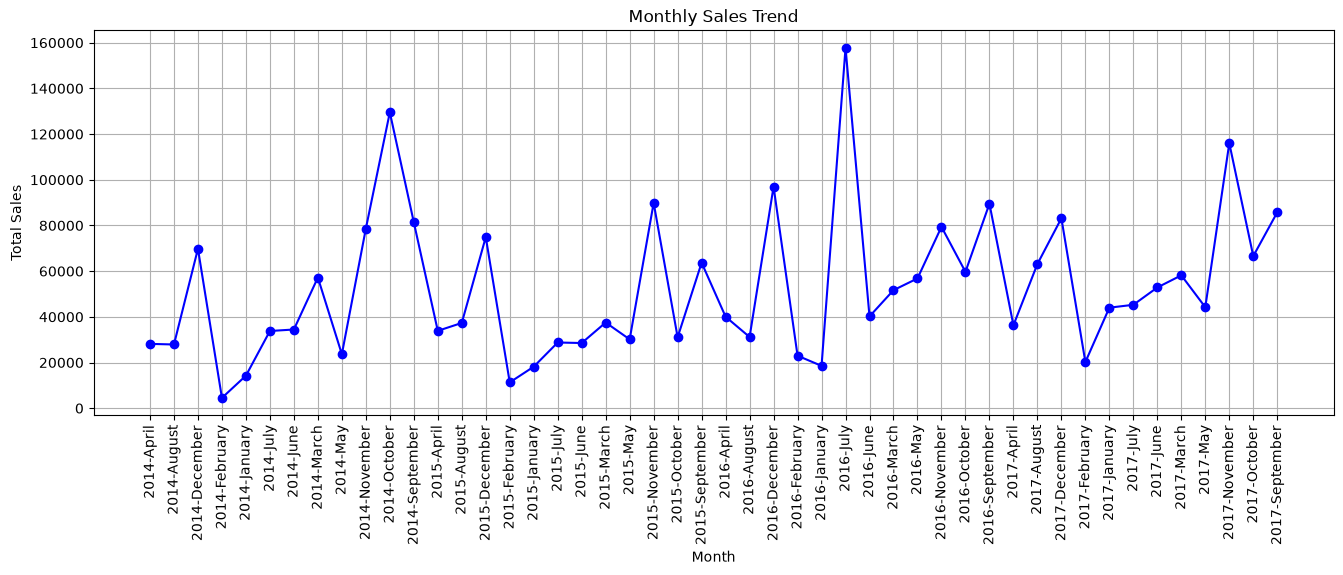

In [6]:
plt.figure(figsize=(16,5))
plt.plot(monthly_sales["Month_Label"],monthly_sales["Sales"],marker="o",color="blue")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

In [7]:
sales_by_category=df.groupby("Category")["Sales"].sum().reset_index()
print(sales_by_category)

          Category        Sales
0        Furniture  872884.5089
1  Office Supplies  733030.3500
2       Technology  922811.7390


C:\Users\admin\AppData\Local\Temp\ipykernel_668\3904838239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Sales",data=sales_by_category,palette="pastel")


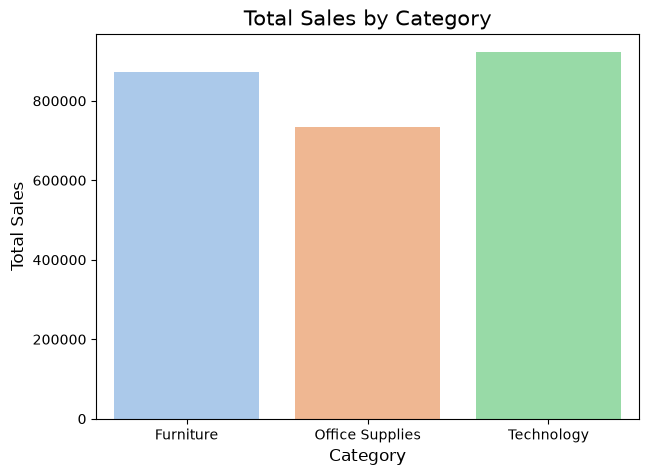

In [8]:
plt.figure(figsize=(7,5))
sns.barplot(x="Category",y="Sales",data=sales_by_category,palette="pastel")

plt.xlabel("Category",fontsize=12)
plt.ylabel("Total Sales",fontsize=12)
plt.title("Total Sales by Category",fontsize=15)

plt.show()


In [9]:
Profit_by_category=df.groupby("Category")["Profit"].sum().reset_index()
print(Profit_by_category)

          Category       Profit
0        Furniture   18179.4889
1  Office Supplies  122845.6772
2       Technology  141200.3169


C:\Users\admin\AppData\Local\Temp\ipykernel_668\2876699100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Profit",data=Profit_by_category,palette="pastel")


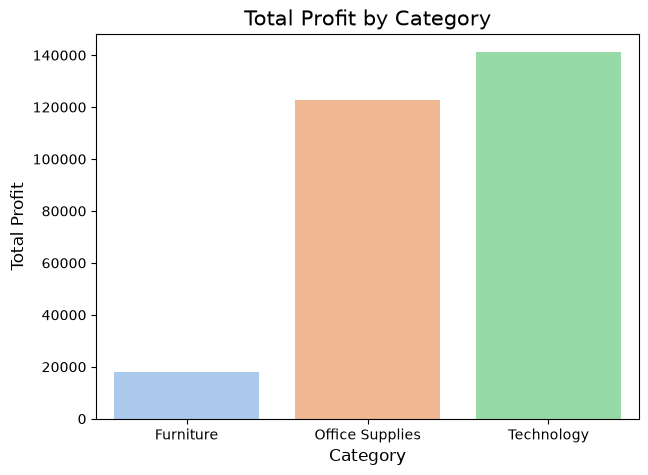

In [10]:
plt.figure(figsize=(7,5))
sns.barplot(x="Category",y="Profit",data=Profit_by_category,palette="pastel")

plt.xlabel("Category",fontsize=12)
plt.ylabel("Total Profit",fontsize=12)
plt.title("Total Profit by Category",fontsize=15)

plt.show()

In [16]:
Profit_by_sub_category=df.groupby("Sub-Category")["Profit"].sum().reset_index()
print(Profit_by_sub_category)

   Sub-Category      Profit
0   Accessories  41797.4636
1    Appliances  18051.3931
2           Art   6510.5500
3       Binders  30863.7847
4     Bookcases  -3459.3964
5        Chairs  26336.9708
6       Copiers  51697.8361
7     Envelopes   6923.8417
8     Fasteners    956.4926
9   Furnishings  12957.3832
10       Labels   5536.3105
11     Machines   3188.0156
12        Paper  33922.7777
13       Phones  44517.0016
14      Storage  21262.8542
15     Supplies  -1182.3273
16       Tables -17655.4687


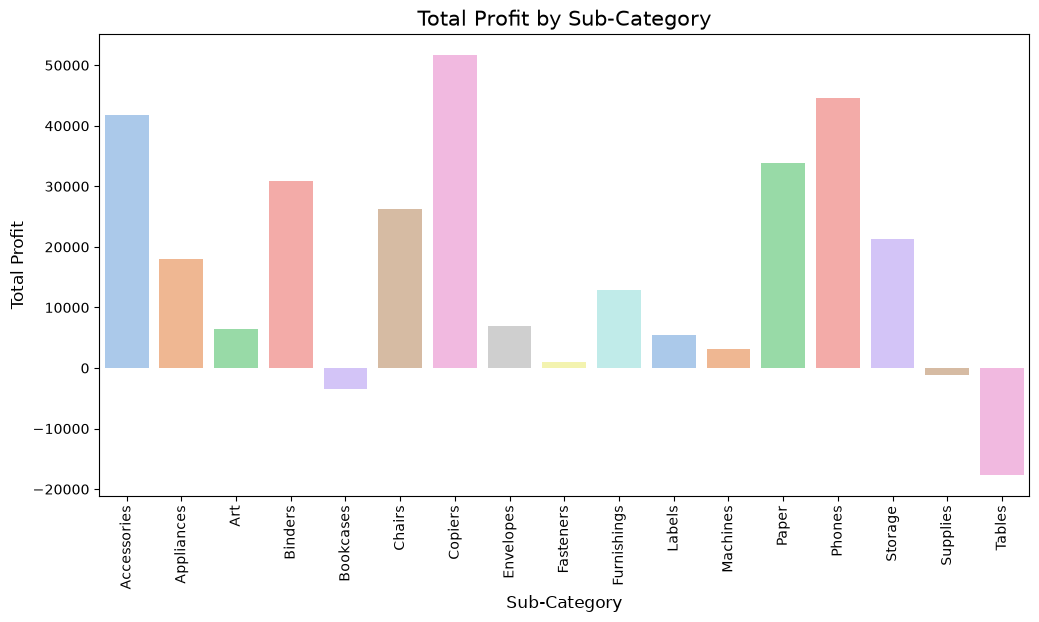

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(x="Sub-Category",y="Profit",data=Profit_by_sub_category,palette="pastel",hue='Sub-Category')

plt.xlabel("Sub-Category",fontsize=12)
plt.ylabel("Total Profit",fontsize=12)
plt.title("Total Profit by Sub-Category",fontsize=15)
plt.xticks(rotation=90)
plt.show()

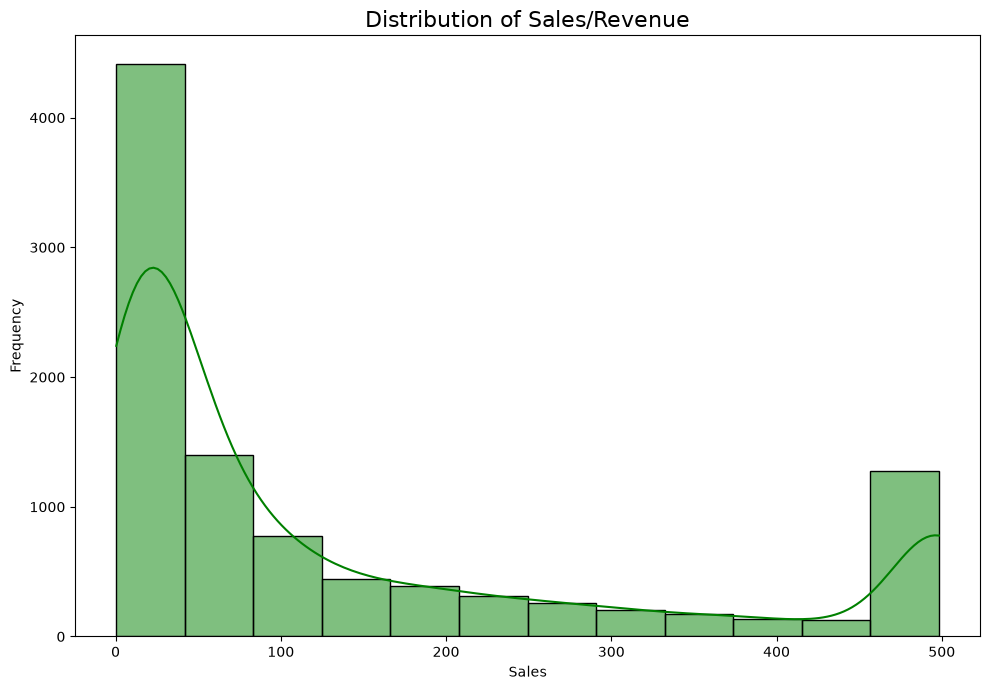

In [ ]:
plt.figure(figsize=(10,7))

sns.histplot(x="Sales",data=df,bins=12,kde=True,color="green")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales/Revenue",fontsize=16)

plt.tight_layout()

plt.show()

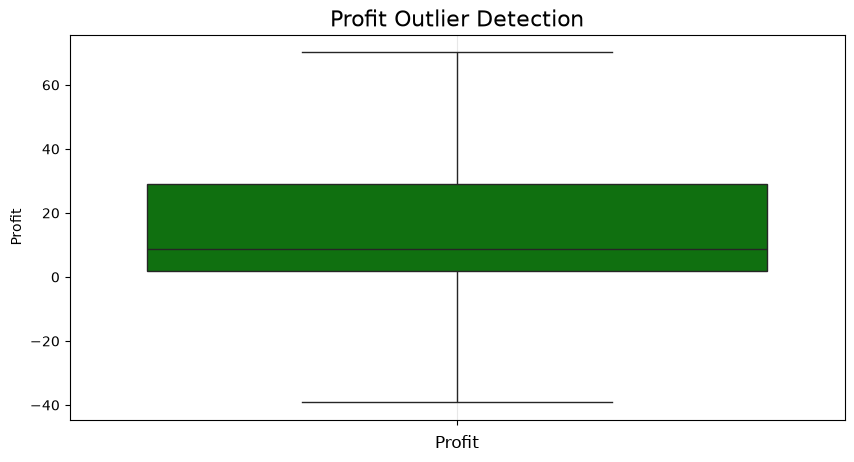

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(y="Profit", data=df, color="green", showfliers=False)

plt.xlabel("Profit", fontsize=12)
plt.title("Profit Outlier Detection", fontsize=16)
plt.grid(axis="x", alpha=0.3)

plt.show()

In [ ]:
profit_q1=df["Profit"].quantile(0.25)
profit_q3=df["Profit"].quantile(0.75)
profit_iqr=profit_q3-profit_q1

profit_lower=profit_q1-1.5*profit_iqr
profit_upper=profit_q3+1.5*profit_iqr

profit_outliers=df[(df["Profit"]<profit_lower) | (df["Profit"]>profit_upper)]

print("1. There are",len(profit_outliers),"extreme profit/loss values")
print("2. Outliers are important because they show very high profit or loss orders")
print("3. All outliers should not be removed without checking the reason")

1. There are 1868 extreme profit/loss values
2. Outliers are important because they show very high profit or loss orders
3. All outliers should not be removed without checking the reason


C:\Users\pbawa\AppData\Local\Temp\ipykernel_6588\1055471591.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Region",data=df,order=region_order,palette="pastel")


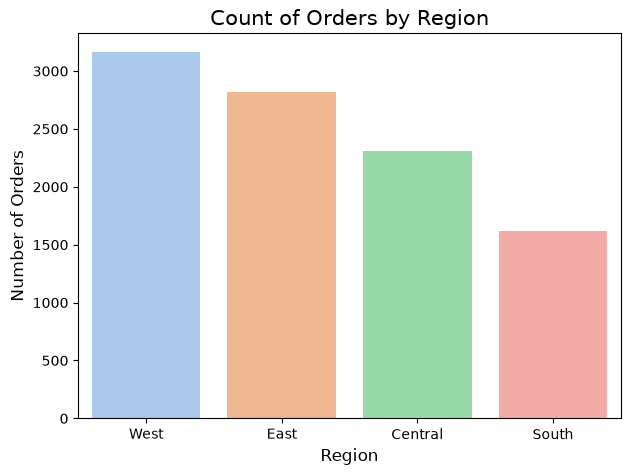

In [ ]:
region_order=df["Region"].value_counts().index

plt.figure(figsize=(7,5))
sns.countplot(x="Region",data=df,order=region_order,palette="pastel")

plt.xlabel("Region",fontsize=12)
plt.ylabel("Number of Orders",fontsize=12)
plt.title("Count of Orders by Region",fontsize=15)

plt.show()

In [ ]:
region_count=df["Region"].value_counts()
print(region_count)

print("1. Region with highest orders is",region_count.idxmax())
print("2. Region with lowest orders is",region_count.idxmin())
print("3. More orders does not always mean more profit")

Region
West       3167
East       2821
Central    2310
South      1616
Name: count, dtype: int64
1. Region with highest orders is West
2. Region with lowest orders is South
3. More orders does not always mean more profit


In [ ]:
average_profit_category=df.groupby("Category")["Profit"].mean().reset_index()
print(average_profit_category)

          Category     Profit
0        Furniture   8.349134
1  Office Supplies  20.468015
2       Technology  76.607083


C:\Users\pbawa\AppData\Local\Temp\ipykernel_13240\4136143090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category",y="Profit",data=average_profit_category,palette="pastel")


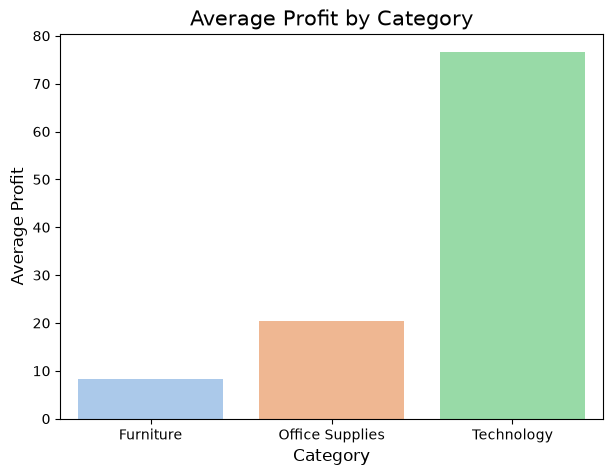

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x="Category",y="Profit",data=average_profit_category,palette="pastel")

plt.xlabel("Category",fontsize=12)
plt.ylabel("Average Profit",fontsize=12)
plt.title("Average Profit by Category",fontsize=15)

plt.show()

In [ ]:
highest_category = average_profit_category.sort_values(by="Profit", ascending=False).iloc[0]["Category"]
lowest_category = average_profit_category.sort_values(by="Profit", ascending=True).iloc[0]["Category"]

print("1. Category with highest average profit is", highest_category)
print("2. Category with lowest average profit is", lowest_category)
print("3. High sales is not always equal to high average profit")

1. Category with highest average profit is Technology
2. Category with lowest average profit is Furniture
3. High sales is not always equal to high average profit


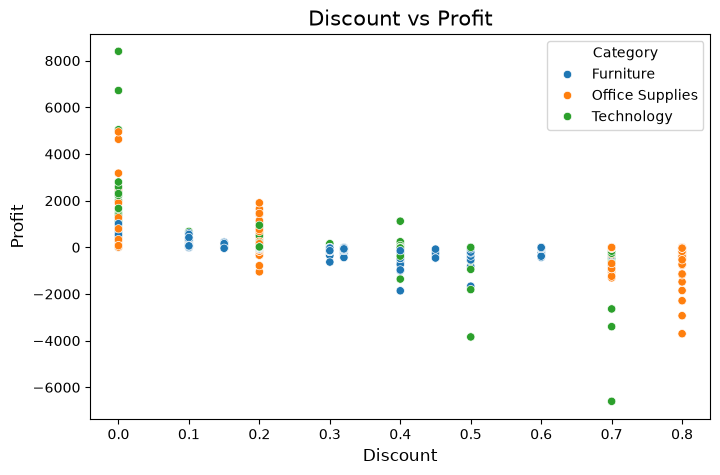

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Discount",y="Profit",data=df,hue="Category")

plt.xlabel("Discount",fontsize=12)
plt.ylabel("Profit",fontsize=12)
plt.title("Discount vs Profit",fontsize=15)

plt.show()

In [ ]:
discount_profit=df["Discount"].corr(df["Profit"])
discount_category=df[df["Discount"]>0].groupby("Category")["Profit"].mean()

print("1. Discount and profit correlation is",round(discount_profit,2))
print("2. Category most affected by discount is",discount_category.idxmin())
print("3. Discount can be an important feature for machine learning")

1. Discount and profit correlation is -0.22
2. Category most affected by discount is Furniture
3. Discount can be an important feature for machine learning


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Category",y="Profit",data=df,palette="pastel",showfliers=False)

plt.xlabel("Category",fontsize=12)
plt.ylabel("Profit",fontsize=12)
plt.title("Profit Distribution by Category",fontsize=15)

plt.show()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Delivery Days,Profit Margin,Profit Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.960,2,0.00,41.9136,2016,11,November,3,16.000000,Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,498.240,3,0.00,219.5820,2016,11,November,3,44.071532,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.620,2,0.00,6.8714,2016,6,June,4,47.000000,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,498.240,5,0.45,-383.0310,2015,10,October,7,-76.876806,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.368,2,0.20,2.5164,2015,10,October,7,11.250000,Profit


In [ ]:
profit_variation=df.groupby("Category")["Profit"].std()
loss_category=df[df["Profit"]<0]["Category"].value_counts()

print("1. Category with more profit variation is",profit_variation.idxmax())
print("2. Category with more loss-making orders is",loss_category.idxmax())
print("3. Yes, there are visible outliers")

1. Category with more profit variation is Technology
2. Category with more loss-making orders is Office Supplies
3. Yes, there are visible outliers


C:\Users\pbawa\AppData\Local\Temp\ipykernel_13240\3547408394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Profit Status",data=df,palette="pastel")


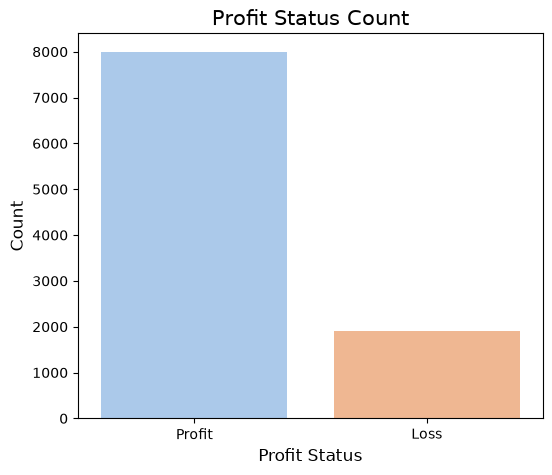

In [ ]:


plt.figure(figsize=(6,5))
sns.countplot(x="Profit Status",data=df,palette="pastel")

plt.xlabel("Profit Status",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.title("Profit Status Count",fontsize=15)

plt.show()


In [ ]:
profit_status_count=df["Profit Status"].value_counts()
print(profit_status_count)

print("1. There are more",profit_status_count.idxmax(),"orders")
if profit_status_count.max()-profit_status_count.min()>0.20*len(df):
    print("2. The target column is imbalanced")
else:
    print("2. The target column is balanced")
print("3. This is important before classification models because imbalance can affect model performance")

Profit Status
Profit    8065
Loss      1849
Name: count, dtype: int64
1. There are more Profit orders
2. The target column is imbalanced
3. This is important before classification models because imbalance can affect model performance


In [ ]:
num_cols=df.select_dtypes(include="number")
corr=num_cols.corr().T
print(corr)

                 Row ID  Postal Code     Sales  Quantity  Discount    Profit  \
Row ID         1.000000     0.008256 -0.009734 -0.005769  0.012672  0.013666   
Postal Code    0.008256     1.000000 -0.010737  0.013040  0.057870 -0.028496   
Sales         -0.009734    -0.010737  1.000000  0.265141 -0.060356  0.181526   
Quantity      -0.005769     0.013040  0.265141  1.000000  0.007563  0.066933   
Discount       0.012672     0.057870 -0.060356  0.007563  1.000000 -0.221437   
Profit         0.013666    -0.028496  0.181526  0.066933 -0.221437  1.000000   
Order Year     0.015227     0.004832 -0.018277 -0.004043 -0.002724  0.003760   
Order Month   -0.018592     0.026109  0.013944  0.023735 -0.005579 -0.000898   
Delivery Days -0.001349    -0.009907 -0.013391  0.018355  0.001173 -0.002818   
Profit Margin -0.004761    -0.057798  0.071415  0.026752 -0.688016  0.756091   

               Order Year  Order Month  Delivery Days  Profit Margin  
Row ID           0.015227    -0.018592      -0.0

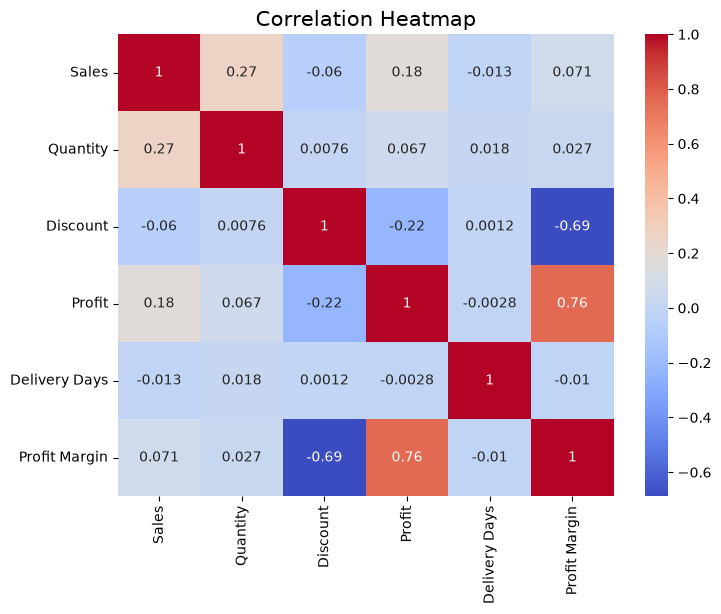

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap",fontsize=15)

plt.show()

In [ ]:
print("1. Sales and Profit are positively correlated")
print("2. Discount and Profit are negatively correlated")
print("3. Discount has a negative relation with profit")
print("4. Sales, Quantity, Discount, Delivery Days and Profit Margin can be useful for predicting profit or loss")

1. Sales and Profit are positively correlated
2. Discount and Profit are negatively correlated
3. Discount has a negative relation with profit
4. Sales, Quantity, Discount, Delivery Days and Profit Margin can be useful for predicting profit or loss


In [ ]:
highest_sales_category=df.groupby("Category")["Sales"].sum().idxmax()
highest_profit_category=df.groupby("Category")["Profit"].sum().idxmax()
loss_sub_category=df.groupby("Sub-Category")["Profit"].sum().idxmin()
most_orders_region=df["Region"].value_counts().idxmax()

sales_q1=df["Sales"].quantile(0.25)
sales_q3=df["Sales"].quantile(0.75)
sales_iqr=sales_q3-sales_q1
sales_lower=sales_q1-1.5*sales_iqr
sales_upper=sales_q3+1.5*sales_iqr
sales_outliers=df[(df["Sales"]<sales_lower) | (df["Sales"]>sales_upper)]

print("1. Highest sales category is",highest_sales_category)
print("2. Highest profit category is",highest_profit_category)
print("3. Loss-making sub-category is",loss_sub_category)
print("4. Region with most orders is",most_orders_region)
print("5. Discount has negative effect on profit")
print("6. There are",len(sales_outliers),"sales outliers")
print("7. Data can be used for profit/loss prediction")
print("8. Useful ML columns are Sales, Quantity, Discount, Delivery Days and Profit Margin")

1. Highest sales category is Office Supplies
2. Highest profit category is Technology
3. Loss-making sub-category is Tables
4. Region with most orders is West
5. Discount has negative effect on profit
6. There are 1156 sales outliers and 1868 profit outliers
7. Data can be used for profit/loss prediction
8. Useful ML columns are Sales, Quantity, Discount, Delivery Days and Profit Margin


In [ ]:
print("1. Superstore data shows sales, profit and discount patterns clearly")
print("2. Highest sales category is",highest_sales_category)
print("3. Highest profit category is",highest_profit_category)
print("4. The main loss-making sub-category is",loss_sub_category)
print("5. Discount reduces profit in many orders")
print("6. Profit and sales have outliers, so they should be checked before modelling")
print("7. Visualization helps us understand trends, losses and unusual values")
print("8. Profit Status can be used as target column for classification")
print("9. Sales, Quantity, Discount, Delivery Days and Profit Margin can help in machine learning")

1. Superstore data shows sales, profit and discount patterns clearly
2. Highest sales category is Office Supplies
3. Highest profit category is Technology
4. The main loss-making sub-category is Tables
5. Discount reduces profit in many orders
6. Profit and sales have outliers, so they should be checked before modelling
7. Visualization helps us understand trends, losses and unusual values
8. Profit Status can be used as target column for classification
9. Sales, Quantity, Discount, Delivery Days and Profit Margin can help in machine learning


In [ ]:
category_comparison=df.groupby("Category")[["Sales","Profit"]].sum().reset_index()
print(category_comparison)

          Category        Sales       Profit
0        Furniture  474080.8684   17524.8316
1  Office Supplies  489471.0960  122419.1969
2       Technology  424397.3770  140497.3903


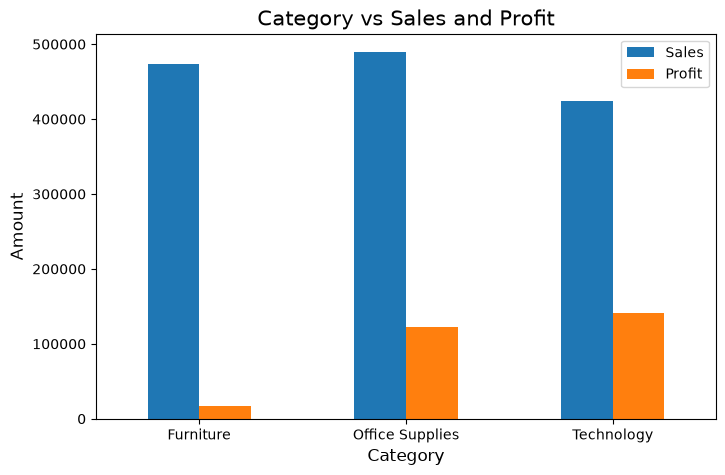

In [ ]:
category_comparison.plot(x="Category",y=["Sales","Profit"],kind="bar",figsize=(8,5))

plt.xlabel("Category",fontsize=12)
plt.ylabel("Amount",fontsize=12)
plt.title("Category vs Sales and Profit",fontsize=15)
plt.xticks(rotation=0)

plt.show()